### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/var/folders/2m/gq3wsnvx7nb8m3z0s863kqmh0000gn/T/ipykernel_6816/3983985159.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


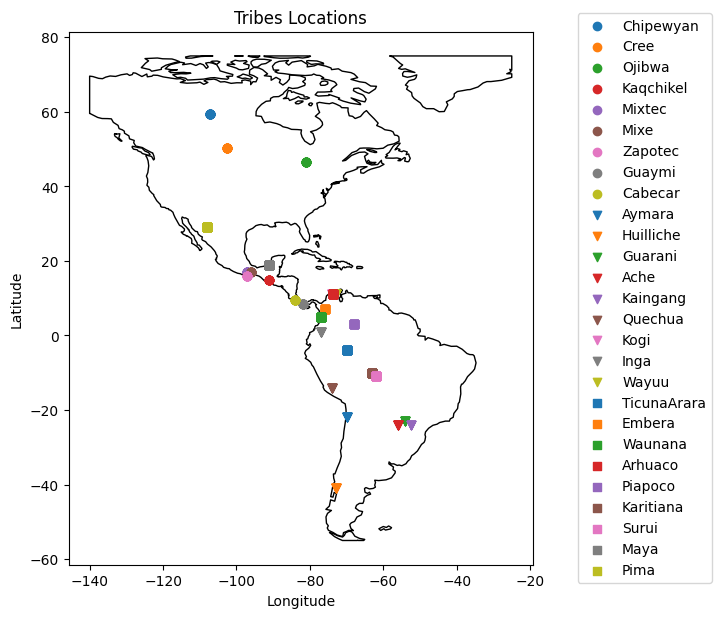

In [6]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$.

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [70]:
import numpy as np

X = df.iloc[:,8:].to_numpy()
y = df.iloc[:,7].to_numpy()

X_with_intercept = np.hstack([np.ones((X.shape[0], 1)), X])

beta = np.linalg.solve(X_with_intercept.T @ X_with_intercept, X_with_intercept.T @ y)

print(beta)


LinAlgError: Singular matrix

#### Explanation

In fact, this error reveals that the matrix $X^\top X$ is singular (non invertible).
This is equivalent to saying that $\text{rank}(X^\top X)$ does not have full column rank , $\text{rank}(X^\top X) < p$.
We can relate to the fact that $\text{rank}(X) < p$, since $\text{rank}(X^\top X) = \text{rank}(X)$ it follows that $\text{rank}(X^\top X) < p$,
which means $X^\top X$ cannot be inverted .



**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result).

And now? Did you get any errors? Why is that?

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [71]:
X = df.iloc[:,8:].to_numpy()
y = df.iloc[:,7].to_numpy()

beta = np.linalg.lstsq(X_with_intercept, y)

print(beta)

(array([-0.47674258, -0.04005413, -0.01943802, ..., -0.2157905 ,
       -0.10203467,  0.01814151], shape=(5710,)), array([], dtype=float64), np.int32(494), array([350.83668173,  61.29683268,  56.47378187,  52.57473959,
        51.42597933,  49.17672028,  46.03130783,  44.22194951,
        42.50706131,  40.19407404,  39.47061754,  37.25350551,
        37.00639096,  36.08915048,  35.17636771,  34.19661859,
        33.91160373,  33.25959937,  32.43740707,  32.0453094 ,
        31.98155247,  31.70591489,  31.5376714 ,  31.11244023,
        30.90093062,  30.84823468,  30.57060543,  30.48592172,
        30.34999078,  30.13923562,  29.93330881,  29.80683119,
        29.72178315,  29.65124152,  29.39439161,  29.33824896,
        29.22446756,  29.03487998,  28.88325273,  28.79252174,
        28.68862365,  28.55668915,  28.46557947,  28.41356243,
        28.2635542 ,  28.21229032,  28.06854465,  28.02216155,
        27.8022999 ,  27.75150492,  27.73683588,  27.6898159 ,
        27.64405109,  27.

#### Explanation

In fact it does work, because the function  numpy.linalg.lstsq solve the least squares problem which doesn't require that $X^\top X$ is invertible

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model.

In [72]:
from sklearn.linear_model import LinearRegression
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
print(lr.coef_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]


In fact , the coefficient of Linear Regression aren't the same as in item (b). The reason for doing recentring is now the intercept represents of y in this case longitude when all the predictors are at their mean ( rather than having all predictors null which is meaningless).

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

Geometrically , the PCA tries to find orthogonal axes that reprensents the directions of maximum spread of data points. Therefore the cordinates system will change by using those new axis .


Statistically PCA reduces the dimensionality of a dataset by removing less significant variables and part of the noise. It transforms the original variables into a smaller set of principal components that capture most of the variance in the data. The selected components therefore retain the maximum possible information from the original dataset while using fewer dimension.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

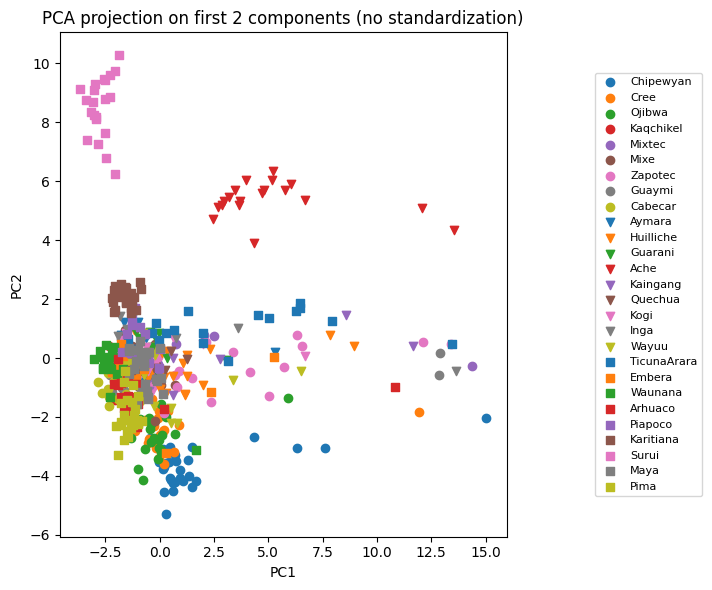

In [73]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA projection on first 2 components (no standardization)')
ax.legend(loc='center right', bbox_to_anchor=(1.45, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

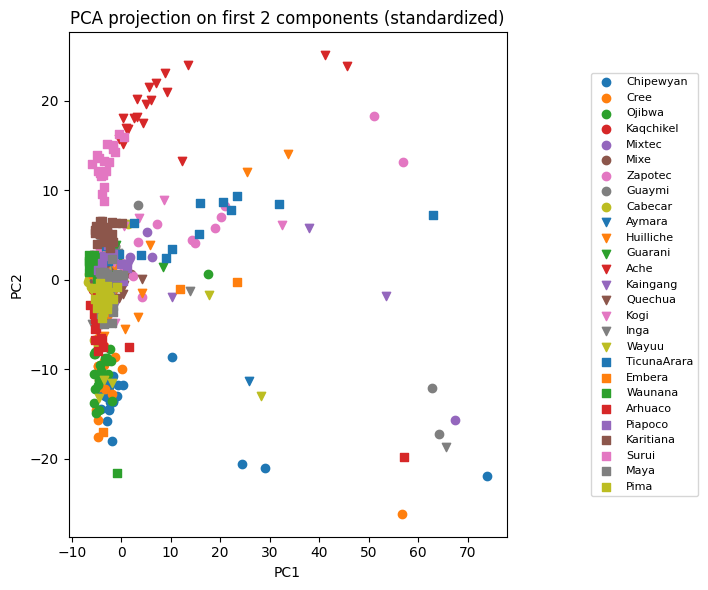

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_std = PCA()
X_pca_std = pca_std.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(8, 6))
for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    ax.scatter(X_pca_std[mask, 0], X_pca_std[mask, 1],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA projection on first 2 components (standardized)')
ax.legend(loc='center right', bbox_to_anchor=(1.45, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

Before the groups are very tightly packed together in the bottom left corner. It is difficult to distinguish the nuances , but now  we can see a clearer separation between groups.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Based on the results, standardizing the data is essential. Before scaling, the PCA projection was biased toward variables with larger magnitudes, leading to a crowded plot where population structures were poorly defined. After applying StandardScaler, the principal components reveal a much clearer separation between groups. This confirms that all predictors must be put on the same scale to ensure that the PCA captures the true variance rather than just  noise."

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [75]:
print('The percentage of variance captured by the first two principal components is'
      , np.round(pca.explained_variance_ratio_[:2].sum() * 100, 2),"%")

The percentage of variance captured by the first two principal components is 3.57 %


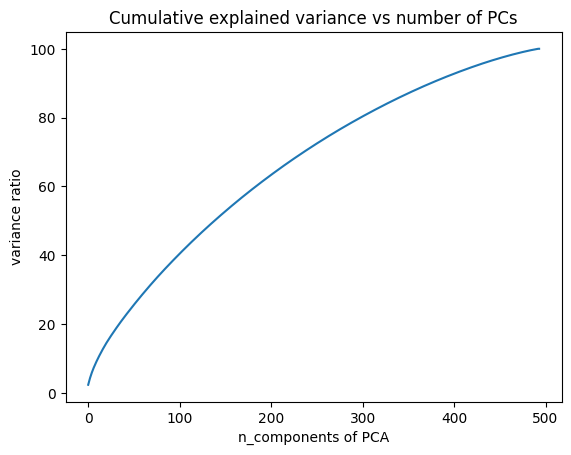

In [76]:
pca = PCA()
pca.fit(X_std)
res = np.cumsum(pca.explained_variance_ratio_) * 100
plt.plot(list(range(494)), res)
plt.xlabel('n_components of PCA')
plt.ylabel('variance ratio')
plt.title('Cumulative explained variance vs number of PCs')
plt.show()

In [77]:
# The minimal number of components such as pourcentage of variance ratio is above 95%
n_components = np.argmax(res>0.95)+1
print('The minimal number of component in PCA such as variance ratio is above 95% is :',n_components)

print(len(gdf['Pop'].unique()))

The minimal number of component in PCA such as variance ratio is above 95% is : 1
27


## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

/var/folders/2m/gq3wsnvx7nb8m3z0s863kqmh0000gn/T/ipykernel_6816/3484988081.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


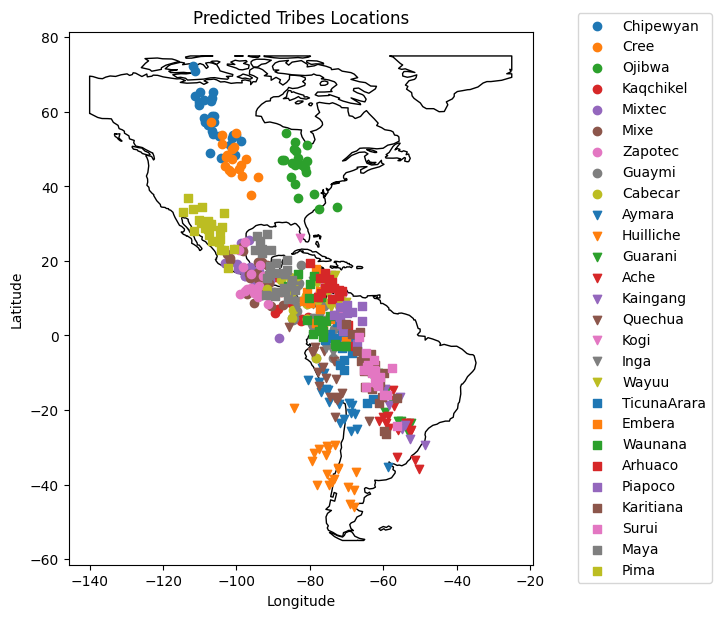

In [78]:
pca_250 = PCA(n_components=250)
lower_X = pca_250.fit_transform(X)
y_lat = df['lat'].values
y_long = df['long'].values
Y = np.column_stack([y_lat, y_long])

lr_pca  = LinearRegression()
lr_pca.fit(lower_X, Y)
y_pred = lr_pca.predict(lower_X)

lat_pred = y_pred[:,0]
long_pred = y_pred[:,1]

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(long_pred, lat_pred))

fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf['Pop'] == tribe
    ax.scatter(long_pred[members_tribe],lat_pred[members_tribe],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The predicted map looks close to the real one, the tribes are roughly in the right geographical areas. However, this result is too optimistic. We are evaluating the model on the same data we used for training (no train/test split), so the model has already seen all these individuals. With 250 PCA components and only 494 samples, the model has a lot of freedom to fit the training data very well, potentially overfitting. The performance on new individuals (not in the database) would likely be worse. To get a realistic estimate of the prediction error, we need to use cross-validation.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [79]:
from sklearn.metrics.pairwise import haversine_distances

real_coords_rad = np.radians(np.column_stack([y_lat, y_long]))
pred_coords_rad = np.radians(np.column_stack([lat_pred, long_pred]))

R_earth = 6371
dists = np.array([
    haversine_distances([real_coords_rad[i]], [pred_coords_rad[i]])[0, 0]
    for i in range(len(y_lat))
]) * R_earth

mean_error = dists.mean()
print(f"Mean distance error (training): {mean_error:.2f} km")

Mean distance error (training): 633.23 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates.

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation is a technique to estimate how well a model generalizes to unseen data. The idea is to split the dataset into $K$ folds. For each fold, we train the model on $K-1$ folds and evaluate it on the remaining one. We repeat this $K$ times (each fold serves as the test set once) and average the errors. This gives a much more honest estimate of the prediction error than just evaluating on the training set.

It is useful because it helps us detect overfitting, a model that has low training error but high cross-validation error is overfitting. It also helps us choose hyperparameters (like the number of PCA components) by comparing cross-validation errors across different settings.

When the samples are not independent and identically distributed, the standard K-fold split can be problematic. For example, if samples from the same group are correlated, a random split might put very similar samples in both train and test, leading to overoptimistic error estimates. In such cases, we should use grouped or stratified cross-validation strategies:
- GroupKFold: ensures that all samples from the same group stay together in either train or test (never split across folds)
- StratifiedKFold: ensures each fold has roughly the same proportion of each class/group
- For time series data, TimeSeriesSplit respects the temporal order

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Looking at the dataset, the rows are ordered by tribe/country, individuals from the same population are grouped together. Within a tribe, individuals are genetically very similar (they share genetic heritage). If we use a simple `KFold`, consecutive samples from the same tribe would likely end up in both train and test folds, making the predictions artificially easy (the model just memorizes tribe-level patterns).

The most adequate choice here is `KFold` with `shuffle=True`. We want to shuffle because the data is ordered by population, and without shuffling consecutive folds would contain entire tribes. Shuffling distributes individuals from each tribe across the folds more evenly. 

We could also use `GroupKFold` with groups being the tribes, which would be even more general (testing on entire unseen tribes). However, that would answer a different question ("can we predict the location of a completely new tribe?") rather than what we want here ("can we predict the location of a new individual?"). So shuffled KFold is a good compromise for our use case.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [80]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold

def haversine_error_km(y_true, y_pred):
    R_earth = 6371
    true_rad = np.radians(y_true)
    pred_rad = np.radians(y_pred)
    dists = np.array([
        haversine_distances([true_rad[i]], [pred_rad[i]])[0, 0]
        for i in range(len(y_true))
    ]) * R_earth
    return dists.mean()

Y = np.column_stack([df['lat'].values, df['long'].values])

# PCA then linear regression (avoids data leakage)
pipe = make_pipeline(PCA(n_components=4), LinearRegression())

kf = KFold(n_splits=10, shuffle=True, random_state=42)

train_errors = []
test_errors = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    pipe.fit(X_train, Y_train)
    
    Y_pred_train = pipe.predict(X_train)
    Y_pred_test = pipe.predict(X_test)
    
    train_errors.append(haversine_error_km(Y_train, Y_pred_train))
    test_errors.append(haversine_error_km(Y_test, Y_pred_test))

print(f"n_components = 4")
print(f"Mean train error: {np.mean(train_errors):.2f} km")
print(f"Mean test error:  {np.mean(test_errors):.2f} km")


n_components = 4
Mean train error: 1808.32 km
Mean test error:  1878.43 km


Using a pipeline is important here: the PCA must be fitted only on the training fold, and then the test fold is transformed using the same PCA transform. If we had done PCA on the whole dataset before splitting, the test data information would leak into the PCA components, which would give an overly optimistic error estimate.

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

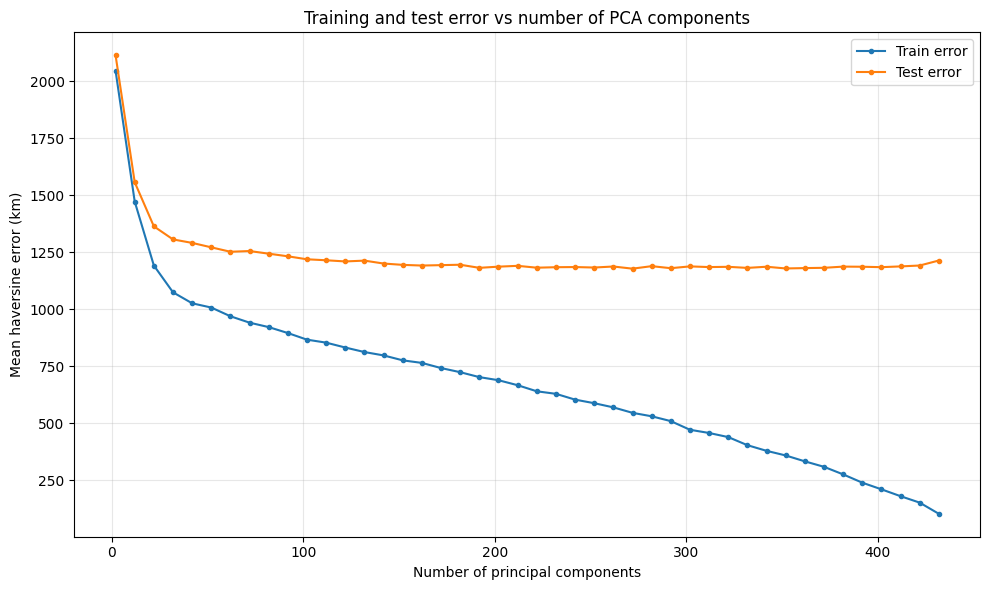

Best n_components: 272
Best test error: 1177.42 km
Corresponding train error: 545.02 km


In [81]:
n_components_range = range(2, 441, 10)
mean_train_errors = []
mean_test_errors = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for n_comp in n_components_range:
    pipe = make_pipeline(PCA(n_components=n_comp), LinearRegression())
    
    fold_train = []
    fold_test = []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        
        pipe.fit(X_train, Y_train)
        
        Y_pred_train = pipe.predict(X_train)
        Y_pred_test = pipe.predict(X_test)
        
        fold_train.append(haversine_error_km(Y_train, Y_pred_train))
        fold_test.append(haversine_error_km(Y_test, Y_pred_test))
    
    mean_train_errors.append(np.mean(fold_train))
    mean_test_errors.append(np.mean(fold_test))

# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(n_components_range), mean_train_errors, 'o-', label='Train error', markersize=3)
ax.plot(list(n_components_range), mean_test_errors, 'o-', label='Test error', markersize=3)
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Mean haversine error (km)')
ax.set_title('Training and test error vs number of PCA components')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# find optimal
best_idx = np.argmin(mean_test_errors)
best_n = list(n_components_range)[best_idx]
print(f"Best n_components: {best_n}")
print(f"Best test error: {mean_test_errors[best_idx]:.2f} km")
print(f"Corresponding train error: {mean_train_errors[best_idx]:.2f} km")

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

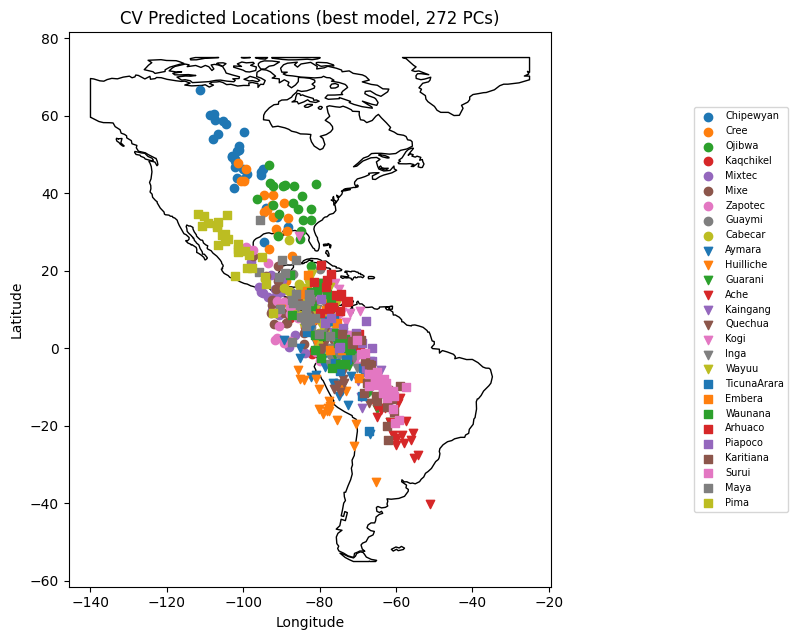

Best model: 272 PCs
Training error (full refit): 596.59 km
CV test error: 1192.89 km


In [82]:
best_pipe = make_pipeline(PCA(n_components=best_n), LinearRegression())
best_pipe.fit(X, Y)
Y_pred_best = best_pipe.predict(X)

lat_pred_best = Y_pred_best[:, 0]
long_pred_best = Y_pred_best[:, 1]

Y_pred_cv = np.zeros_like(Y)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
pipe_best = make_pipeline(PCA(n_components=best_n), LinearRegression())

for train_idx, test_idx in kf.split(X):
    pipe_best.fit(X[train_idx], Y[train_idx])
    Y_pred_cv[test_idx] = pipe_best.predict(X[test_idx])


world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]


world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    ax.scatter(Y_pred_cv[mask, 1], Y_pred_cv[mask, 0],
               marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
ax.set_title(f'CV Predicted Locations (best model, {best_n} PCs)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), fontsize=7)

plt.tight_layout()
plt.show()

cv_error = haversine_error_km(Y, Y_pred_cv)
train_error = haversine_error_km(Y, Y_pred_best)
print(f"Best model: {best_n} PCs")
print(f"Training error (full refit): {train_error:.2f} km")
print(f"CV test error: {cv_error:.2f} km")

We keep the model with the number of PCs that gives the lowest cross-validation test error. The gap between training and test error shows some overfitting, but the model still manages to predict the general geographic area of each individual from its genetic markers. The CV-predicted map shows that the broad north-south and east-west patterns are captured, though predictions within the same region tend to cluster together more than the real locations (the model can't distinguish finely between nearby tribes). This is a more realistic picture of the model's actual predictive power compared to Exercise 4 where we evaluated on the training set.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

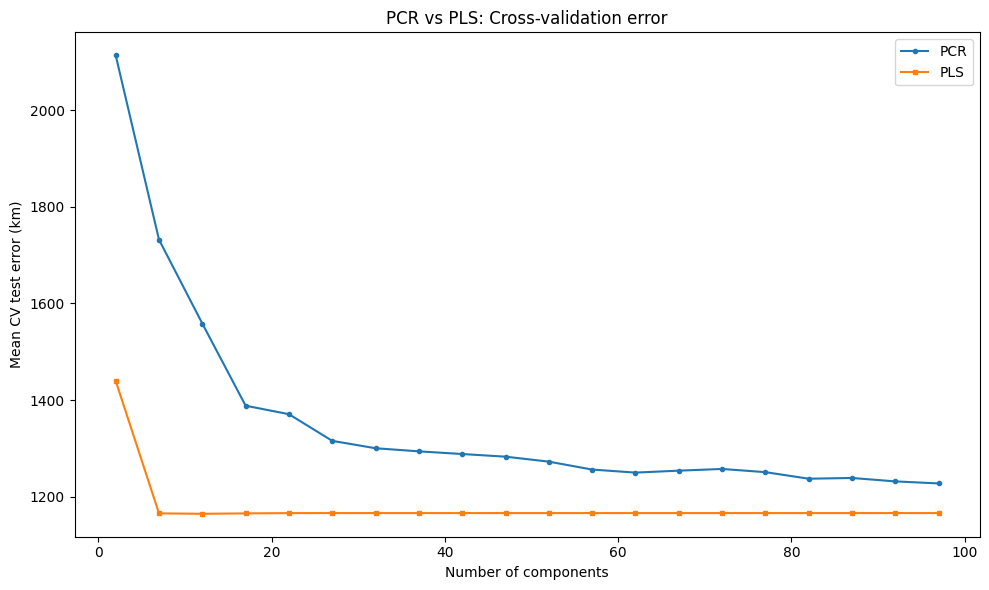

Error per country (best PCR model, CV predictions):
  Canada              : 1493.67 km
  Guatemala           : 1688.36 km
  Mexico              : 1092.51 km
  Panama              : 753.65 km
  CostaRica           : 678.06 km
  Chile               : 2702.29 km
  Brazil              : 1160.11 km
  Paraguay            : 745.26 km
  Peru                : 1547.45 km
  Colombia            : 798.60 km


In [83]:
from sklearn.cross_decomposition import PLSRegression

# PCR vs PLS
n_components_range_cmp = range(2, 102, 5)
pcr_test_errors = []
pls_test_errors = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for n_comp in n_components_range_cmp:
    # PCR
    pcr_pipe = make_pipeline(PCA(n_components=n_comp), LinearRegression())
    pcr_fold = []
    for train_idx, test_idx in kf.split(X):
        pcr_pipe.fit(X[train_idx], Y[train_idx])
        Y_pred = pcr_pipe.predict(X[test_idx])
        pcr_fold.append(haversine_error_km(Y[test_idx], Y_pred))
    pcr_test_errors.append(np.mean(pcr_fold))
    
    # PLS
    pls = PLSRegression(n_components=n_comp)
    pls_fold = []
    for train_idx, test_idx in kf.split(X):
        pls.fit(X[train_idx], Y[train_idx])
        Y_pred = pls.predict(X[test_idx])
        pls_fold.append(haversine_error_km(Y[test_idx], Y_pred))
    pls_test_errors.append(np.mean(pls_fold))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(n_components_range_cmp), pcr_test_errors, 'o-', label='PCR', markersize=3)
ax.plot(list(n_components_range_cmp), pls_test_errors, 's-', label='PLS', markersize=3)
ax.set_xlabel('Number of components')
ax.set_ylabel('Mean CV test error (km)')
ax.set_title('PCR vs PLS: Cross-validation error')
ax.legend()
plt.tight_layout()
plt.show()

# Error per country
# use the best PCR model CV predictions
countries = df.iloc[:, 3]  # "Country" column
print("Error per country (best PCR model, CV predictions):")
for country in countries.unique():
    mask = countries == country
    err = haversine_error_km(Y[mask], Y_pred_cv[mask])
    print(f"  {country:20s}: {err:.2f} km")


### Conclusion

In this TP, we showed that it is possible to predict the geographical origin of indigenous American individuals using their genetic markers, by combining PCA for dimensionality reduction with linear regression (PCR).

**Key findings:**

1. **Dimensionality reduction is necessary**: With $p = 5709$ markers and only $N = 494$ samples, a direct linear regression fails because $X^\top X$ is singular. PCA allows us to reduce the feature space to a manageable number of components while preserving most of the genetic variation.

2. **Model selection via cross-validation**: Using 10-fold cross-validation, we found that the optimal number of PCA components balances between underfitting and overfitting. The training error kept decreasing as we added more components, but the test error eventually increased, a classic bias-variance tradeoff.

3. **PCR vs PLS**: PLS builds components that are correlated with the response (latitude/longitude), while PCA only cares about explaining variance in the predictors $X$ regardless of whether that variance is relevant for prediction. We could expect that PLS will tend to reach better performance with fewer components. In practice, some PCA directions with high variance in the markers may be irrelevant for geographic prediction. 

4. **Per-country performance**: The prediction errors vary across countries. Tribes that are geographically isolated or very distinct genetically tend to be predicted more accurately. Errors are largest for countries/regions where multiple tribes live relatively close together but have different genetic profiles, making it harder for the model to pinpoint the exact location.

5. **Limitations**: Our model predicts the location of the tribe, not the individual. Since individuals from the same tribe share genetic markers and the same location, the regression essentially learns to map genetic clusters to their mean geographic coordinates. Also, the dataset only covers certain populations, so the model wouldn't generalize well to populations not represented in the training data.

**Possible improvements** PLS is already a step in the right direction as shown above, since it constructs components that are more directly relevant for prediction.